In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [3]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset>
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 ...
    longitude          float64 ...
    station_latitude   (station) float64 ...
    station_longitude  (station) float64 ...
Data variables: (12/14)
    u10                (station, valid_time) float32 ...
    v10                (station, valid_time) float32 ...
    d2m                (station, valid_time) float32 ...
    t2m                (station, valid_time) float32 ...
    msl                (station, valid_time) float32 ...
    sst                (station, valid_time) float32 ...
    ...                 ...
    mwd                (station, valid_time) float32 ...
    mwp                (station, valid_time) float32 ...
    swh                (station, valid_

In [4]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")

In [6]:
from numba import njit
import numpy as np
import xarray as xr
from numba import njit

@njit(cache=True, fastmath=True)
def _mask_1d(values, k_eff, mean, std, safe_lo, safe_hi,
             hard_clip_eff, p95, p95_margin_eff,
             q1, q3, use_quantiles, iqr_mult):
    n = values.shape[0]
    dev = np.zeros(n, dtype=np.bool_)
    last_kept = np.nan; have_last=False; prev_was_kept=False
    z_enabled = np.isfinite(std) and std > 0.0
    p95_gate = p95 + p95_margin_eff if np.isfinite(p95) else np.inf
    iqr = q3 - q1
    lo_iqr = q1 - iqr_mult * iqr
    hi_iqr = q3 + iqr_mult * iqr
    for i in range(n):
        x = values[i]
        if not np.isfinite(x): dev[i]=True; prev_was_kept=False; continue
        if np.abs(x) > hard_clip_eff: dev[i]=True; prev_was_kept=False; continue
        if (x >= safe_lo) and (x <= safe_hi): dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True; continue
        if use_quantiles and ((x < lo_iqr) or (x > hi_iqr)): dev[i]=True; prev_was_kept=False; continue
        if z_enabled:
            z = (x - mean) / std
            if np.abs(z) > k_eff: dev[i]=True; prev_was_kept=False; continue
        if not prev_was_kept:
            if x <= p95_gate: dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
            else: dev[i]=True; prev_was_kept=False
            continue
        if have_last:
            allowed = 1.5 if (-1.0 <= last_kept <= 1.0) else 0.5
            if np.abs(x - last_kept) > allowed: dev[i]=True; prev_was_kept=False; continue
        dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
    return dev

# FAST block-drift mask: EW-quantile (median) + run-length
@njit(cache=True, fastmath=True)
def _block_mask_1d(values, med_thresh, min_run, alpha):
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    m = 0.0                        # EW median estimate (starts near 0 for residuals)
    run = 0                        # consecutive samples with |m| > threshold
    for i in range(n):
        x = values[i]
        if np.isfinite(x):
            # Robbins–Monro quantile update (tau=0.5 -> median)
            m += alpha * (0.5 - (1.0 if x < m else 0.0))
            if np.abs(m) > med_thresh:
                run += 1
                if run == min_run:
                    # backfill the initial block once threshold run is reached
                    start = i - min_run + 1
                    for j in range(start, i + 1):
                        block[j] = True
                elif run > min_run:
                    block[i] = True
            else:
                run = 0
        else:
            run = 0  # NaN breaks the block
    return block
@njit(cache=True, fastmath=True)
def _yrmean_block_mask_1d(values, yr_mean_vals, good_year_vals,
                          mean_abs_thresh, band, min_run):
    """
    Flag contiguous runs that stay near the (shifted) yearly mean, but only
    in years where |yearly mean| > mean_abs_thresh and coverage was 'good'.
    """
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    run = 0
    start = 0
    for i in range(n):
        x = values[i]
        if not np.isfinite(x):
            run = 0
            continue

        if not good_year_vals[i]:
            # year not eligible: reset run
            run = 0
            continue

        ymean = yr_mean_vals[i]
        if not np.isfinite(ymean) or (np.abs(ymean) <= mean_abs_thresh):
            # yearly mean not "shifted" enough
            run = 0
            continue

        # Are we "near" the shifted yearly mean?
        if np.abs(x - ymean) <= band:
            if run == 0:
                start = i
            run += 1
            if run == min_run:
                for j in range(start, i + 1):
                    block[j] = True
            elif run > min_run:
                block[i] = True
        else:
            run = 0
    return block
def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    base_k: float = 5.0,
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),
    hard_clip: float = 3.0,
    p95_margin: float = 0.5,
    station_dim: str = "station",
    min_frac_year: float = 0.5,
    kurt_hard: float = 1.0,
    # mean-shift block knobs
    year_mean_abs_thresh: float = 1.0,   # consider a year "shifted" if |year mean| > 1 m
    block_band: float = 0.5,             # samples within ±band of the yearly mean count toward a block
    min_run: int = 60,                   # consecutive samples near the mean to declare a block
):
    da = ds[var]; dim = da.dims[0] if dim is None else dim
    ds = ds.sortby(dim); da = ds[var].astype("float64")

    # --- robust stats (unchanged)
    mu   = da.mean(dim=dim, skipna=True)
    sig  = da.std(dim=dim,  skipna=True)
    p95  = da.quantile(0.95, dim=dim, skipna=True)
    qs   = da.quantile([0.25, 0.75], dim=dim, skipna=True)
    q1, q3 = qs.sel(quantile=0.25), qs.sel(quantile=0.75)

    m2 = da.var(dim=dim, skipna=True)
    m4 = ((da - mu) ** 4).mean(dim=dim, skipna=True)
    ex_kurt = xr.where(m2 > 0, m4 / (m2 ** 2) - 3.0, 0.0)
    heavy = ex_kurt > kurt_hard

    k_eff          = xr.where(heavy, base_k / 2.5, base_k)
    iqr_mult       = xr.where(heavy, 1.0, 1.5)
    hard_clip_eff  = xr.where(heavy, 2.0, hard_clip)
    p95_margin_eff = xr.where(heavy, 0.1, p95_margin)
    use_quantiles  = heavy

    dev_point = xr.apply_ufunc(
        _mask_1d,
        da, k_eff, mu, sig,
        xr.DataArray(safe_keep_band[0]), xr.DataArray(safe_keep_band[1]),
        hard_clip_eff, p95, p95_margin_eff,
        q1, q3, use_quantiles, iqr_mult,
        input_core_dims=[[dim], [], [], [], [], [], [], [], [], [], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    # --- yearly mean and coverage (unchanged)
    present = da.notnull()
    cov_year = present.groupby(f"{dim}.year").mean(dim=dim)         # fraction present per year
    yr_mean  = da.groupby(f"{dim}.year").mean(dim=dim, skipna=True)  # mean per year
    good_year = cov_year > min_frac_year

    # --- NEW: broadcast per-year values back to each timestamp by selecting with a per-sample 'year' indexer
    # Ensure time axis is datetime64
    if not np.issubdtype(ds[dim].dtype, np.datetime64):
        # If your coord isn't datetime64, convert it here (one-time)
        ds = ds.assign_coords({dim: xr.converters.to_datetime64(ds[dim])})
        da = ds[var].astype("float64")

    year_indexer = xr.DataArray(
        ds[dim].dt.year,         # vector of years for every sample along `dim`
        dims=dim,
        coords={dim: ds[dim]}
    )

    # These now have the SAME dims as `da` (broadcasted back from 'year')
    yr_mean_full   = yr_mean.sel(year=year_indexer)
    good_year_full = good_year.sel(year=year_indexer)

    # --- block detector: runs near the shifted yearly mean
    dev_block = xr.apply_ufunc(
        _yrmean_block_mask_1d,
        da,
        yr_mean_full,
        good_year_full,
        xr.DataArray(year_mean_abs_thresh),
        xr.DataArray(block_band),
        xr.DataArray(np.int64(min_run)),
        input_core_dims=[[dim], [dim], [dim], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    deviant = dev_point | dev_block

    out = ds.copy()
    out[f"{var}_is_deviant"] = deviant
    out[var] = da.where(~deviant)

    if station_dim in out.dims:
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        cov_check = cov_year if not extra else cov_year.mean(dim=extra)
        keep_station = (cov_check > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]
# ds: xr.Dataset with a variable named "residual" along dimension "time"
ds_filtered, dev_mask = filter_residual(ds, var="residual", dim="valid_time")
ds = ds_filtered

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import xarray as xr

# 1) Annual maxima of sea_level per station
annual_max = ds["residual"].groupby("valid_time.year").max("valid_time", skipna=True)  # (station, year)

# 2) Require at least 10 annual maxima to estimate a 10-yr RL
n_years = annual_max.notnull().sum("year")                                              # (station,)
tenyr_rl = annual_max.quantile(0.9, dim="year", skipna=True)                             # (station,)
tenyr_rl = tenyr_rl.where(n_years >= 3)                                                # mask weak stations

# 3) Pull station coords (1D over 'station')
lons = ds["station_longitude"].values
lats = ds["station_latitude"].values
vals = tenyr_rl.values

# Reuse coords & units from your code
proj = ccrs.PlateCarree()
valid_pts = np.isfinite(lons) & np.isfinite(lats)

def quick_map(values, title, cbarlabel="", cmap="plasma_r", vmin=None, vmax=None, n_clusters=None):
    vals = np.asarray(values)
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10,8))
    ax = plt.axes(projection=proj)

    # Compute valid extent
    valid_pts = np.isfinite(lons) & np.isfinite(lats)
    xmin, xmax = float(np.nanmin(lons[valid_pts])), float(np.nanmax(lons[valid_pts]))
    ymin, ymax = float(np.nanmin(lats[valid_pts])), float(np.nanmax(lats[valid_pts]))
    pad_x = max(0.5, 0.05 * (xmax - xmin))
    pad_y = max(0.5, 0.05 * (ymax - ymin))
    ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)

    # Base map features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="whitesmoke")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.right_labels = False; gl.top_labels = False

    # --- 🔹 Make discrete colorbar if n_clusters is given ---
    if n_clusters is not None and n_clusters > 1:
        cmap_obj = plt.get_cmap(cmap, n_clusters)
        norm = mcolors.BoundaryNorm(np.linspace(vmin, vmax, n_clusters + 1), cmap_obj.N)
    else:
        cmap_obj = plt.get_cmap(cmap)
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Scatter plot
    sc = ax.scatter(lons, lats, c=vals, s=150, cmap=cmap_obj, norm=norm,
                    edgecolor="black", linewidth=0.4, alpha=0.95, transform=proj)

    # Discrete colorbar
    cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
    cb.set_label(cbarlabel)
    if n_clusters is not None and n_clusters > 1:
        cb.set_ticks(np.linspace(vmin, vmax, n_clusters))
        cb.ax.set_yticklabels([f"C{i+1}" for i in range(n_clusters)])  # optional: label by cluster number

    ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [17]:
list(ds.keys())

['u10',
 'v10',
 'd2m',
 't2m',
 'msl',
 'sst',
 'sp',
 'tp',
 'mwd',
 'mwp',
 'swh',
 'sea_level',
 'tide',
 'residual',
 'residual_is_deviant']

# change so that we allow for NaNs

Features shape (unmasked): (157, 73)  |  used stations: 81 / 157
First 10 feature columns: ['d2m__mean', 'd2m__std', 'd2m__skew', 'd2m__kurt', 'd2m__p95', 'd2m__p99', 'msl__mean', 'msl__std', 'msl__skew', 'msl__kurt']


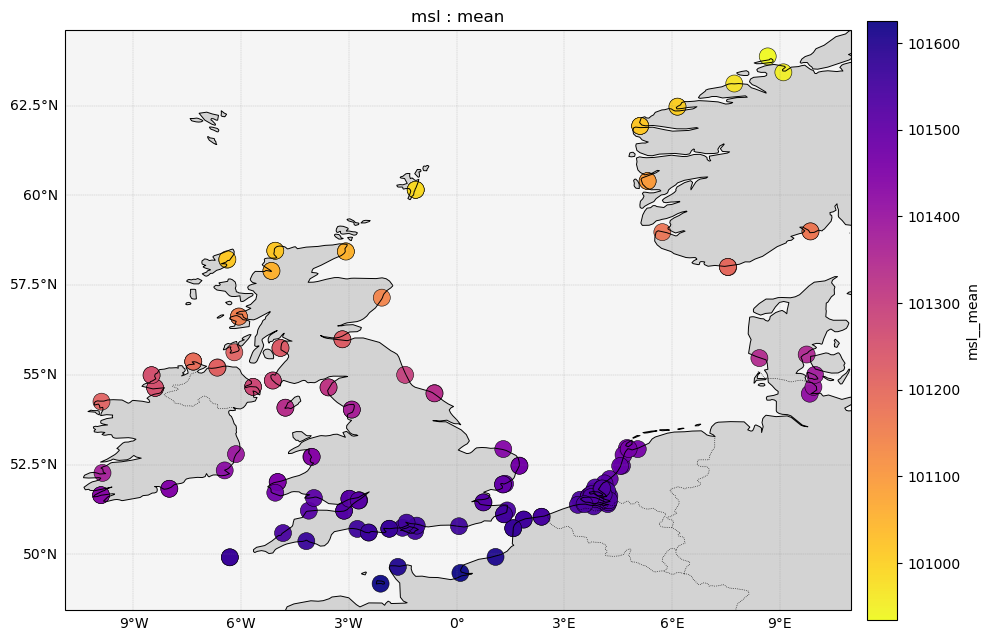

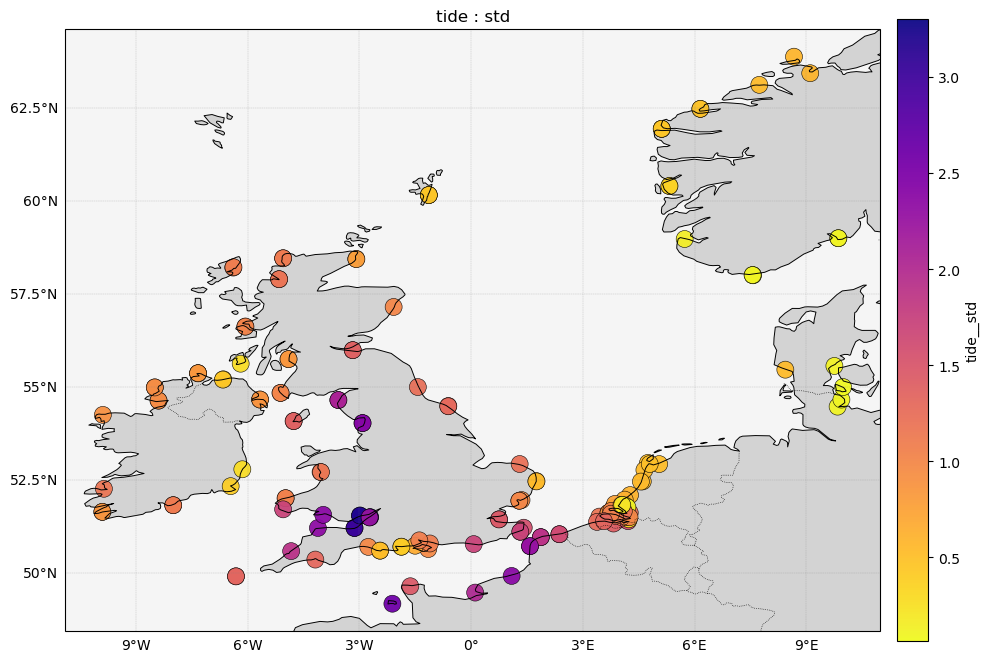

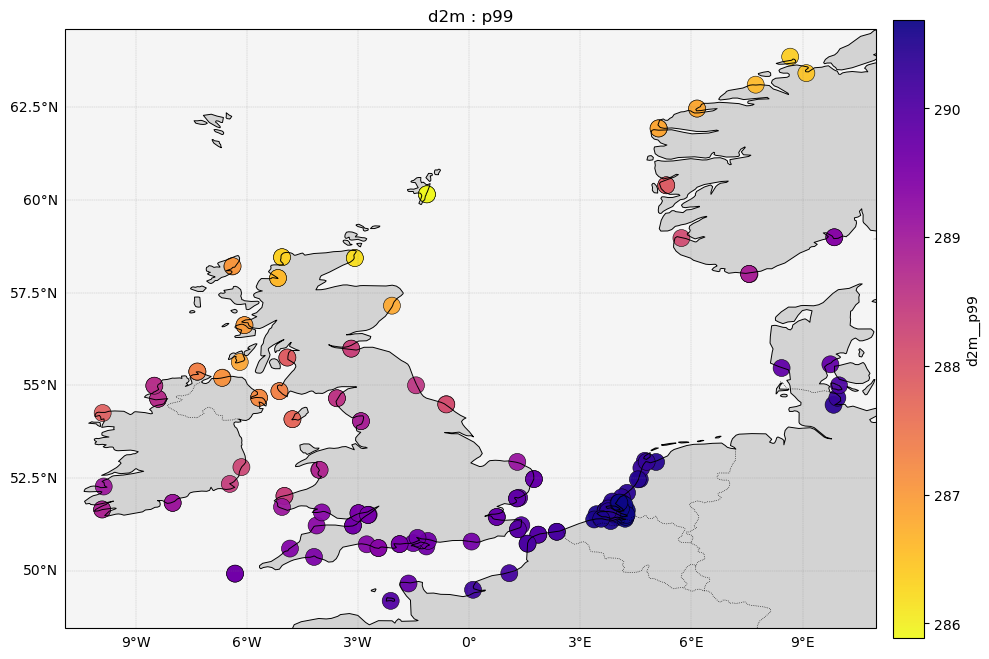

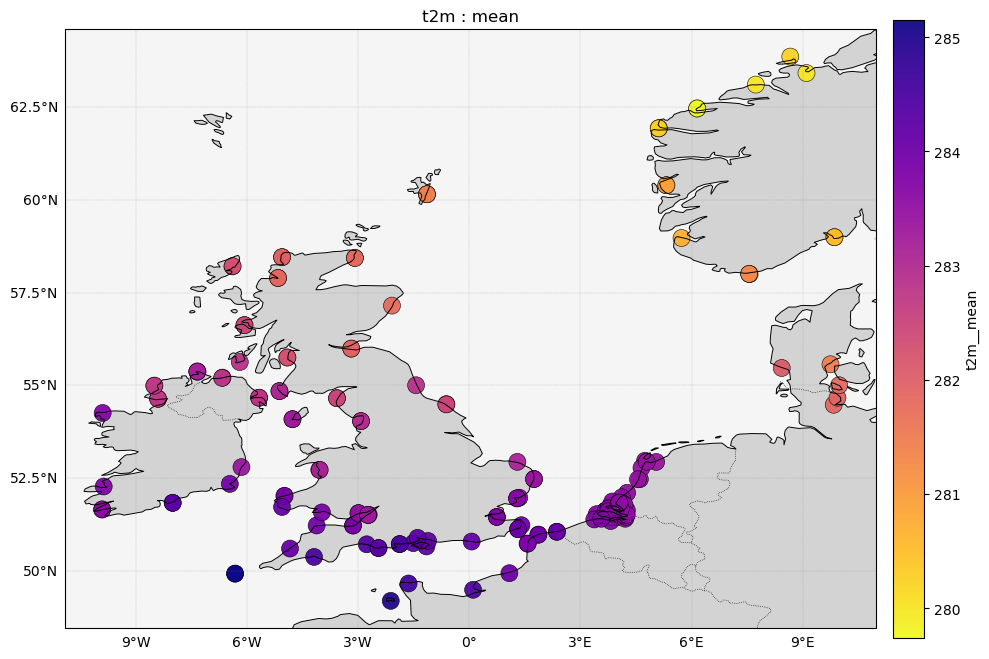

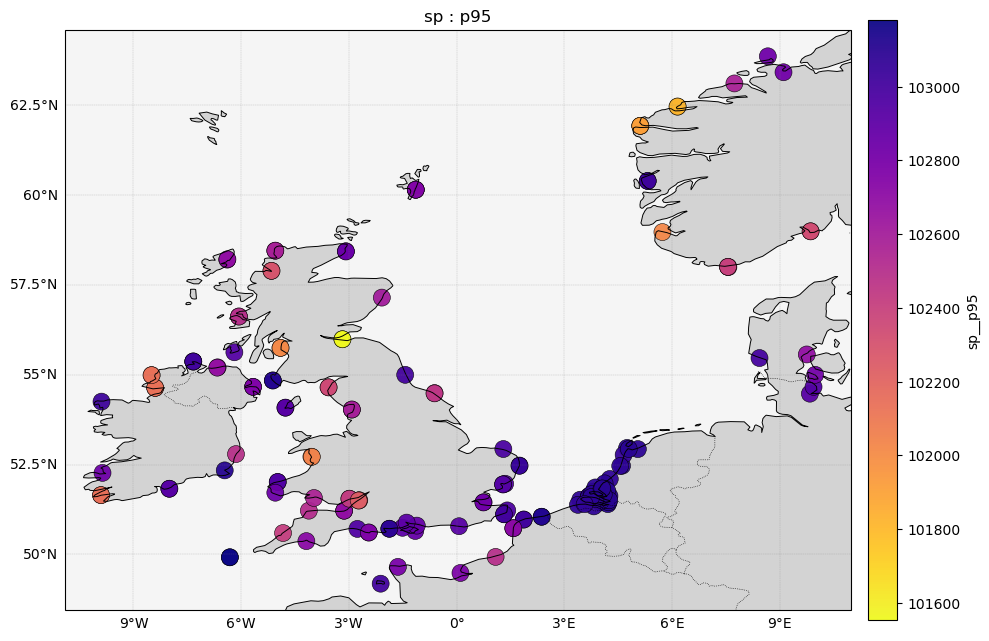

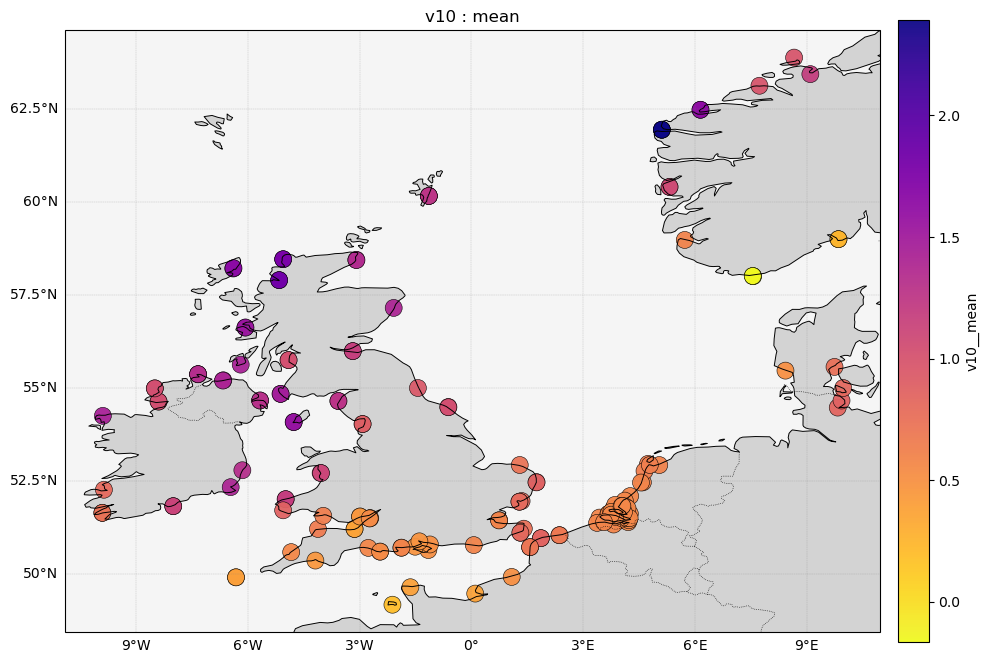

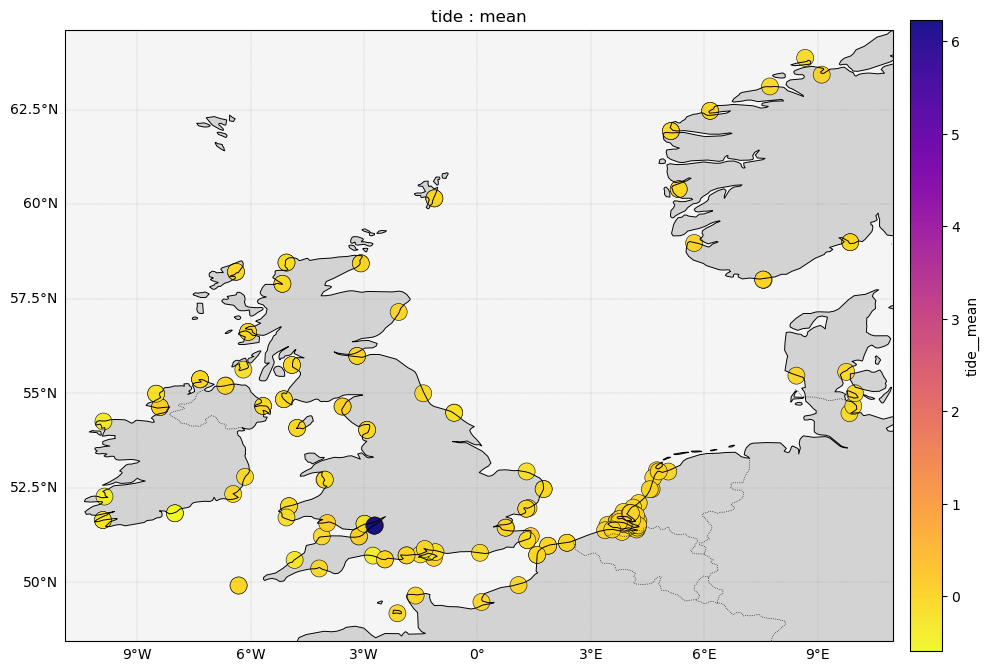

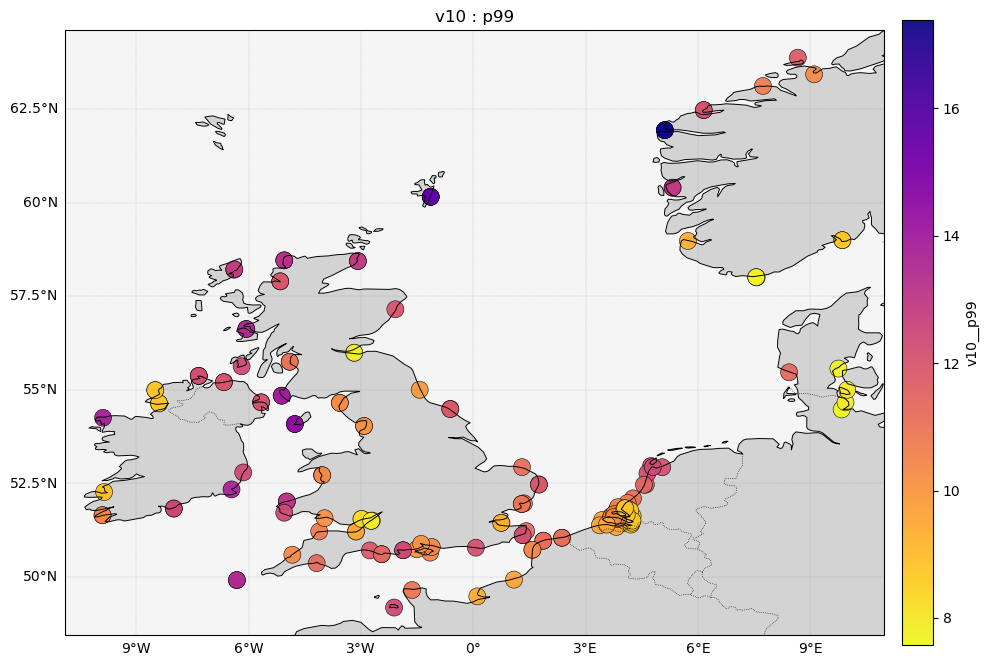

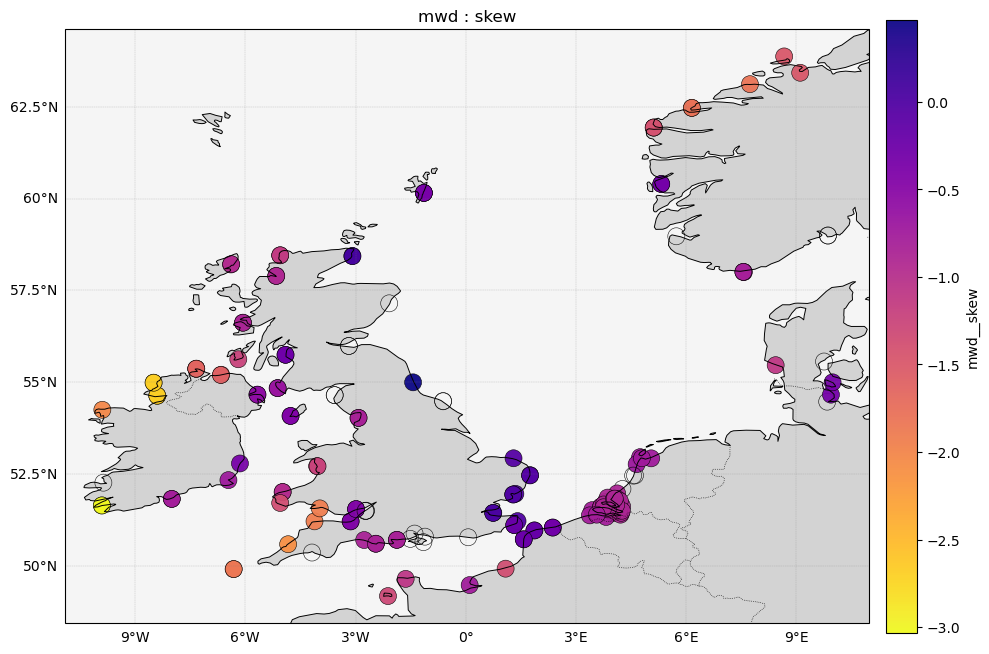

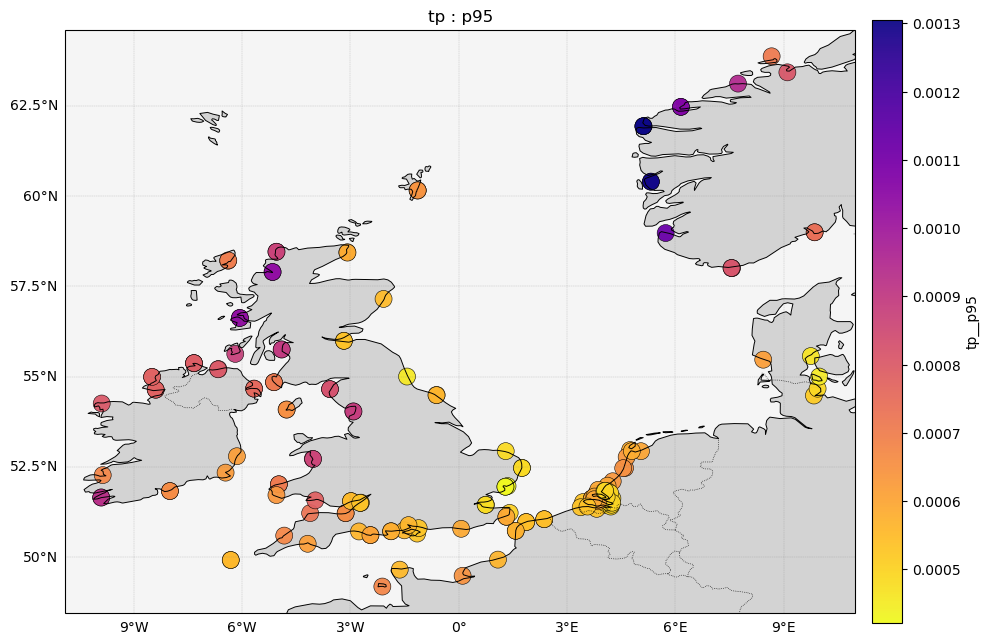

In [19]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------------------------
# 0) Configure variables and helpers
# -------------------------------------------------------------------
vars_all = ['u10','v10','d2m','t2m','msl','sst','sp','tp','mwd','mwp','swh','tide']

def per_station_var(varname, func, min_n=6):
    """Apply a 1D numpy func per-station over time for ds[varname].
    Returns a (station,) array with NaNs where insufficient data."""
    if varname not in ds:
        return None
    out = np.full(ds.sizes["station"], np.nan, dtype=float)
    da = ds[varname]
    # Expect dims to include 'station' and 'valid_time'
    for i in range(ds.sizes["station"]):
        x = da.isel(station=i).values
        x = x[np.isfinite(x)]
        if x.size >= min_n:
            try:
                out[i] = func(x)
            except Exception:
                out[i] = np.nan
    return out

def per_station_mean(varname):
    return ds[varname].mean("valid_time", skipna=True).values if varname in ds else None

def per_station_std(varname):
    return ds[varname].std("valid_time", skipna=True).values if varname in ds else None

# -------------------------------------------------------------------
# 1) Compute stats for every variable
# -------------------------------------------------------------------
stats_dict = {}  # column_name -> (station,) np.ndarray

for v in vars_all:
    if v not in ds:
        # skip missing variables
        continue

    # mean / std via xarray (fast, handles NaNs)
    m = per_station_mean(v)
    s = per_station_std(v)

    # higher-moment & tails via scipy / numpy
    sk = per_station_var(v, lambda x: skew(x, bias=False))
    ku = per_station_var(v, lambda x: kurtosis(x, fisher=True, bias=False))  # excess kurtosis
    p95 = per_station_var(v, lambda x: np.nanpercentile(x, 95))
    p99 = per_station_var(v, lambda x: np.nanpercentile(x, 99))

    # store with informative names
    if m is not None:   stats_dict[f"{v}__mean"] = m
    if s is not None:   stats_dict[f"{v}__std"]  = s
    if sk is not None:  stats_dict[f"{v}__skew"] = sk
    if ku is not None:  stats_dict[f"{v}__kurt"] = ku
    if p95 is not None: stats_dict[f"{v}__p95"]  = p95
    if p99 is not None: stats_dict[f"{v}__p99"]  = p99

# Include your already-computed 10-yr RL for residuals if present
# (tenyr_rl is (station,), NaNs where insufficient years)
if 'tenyr_rl' in globals() and isinstance(tenyr_rl, (np.ndarray,)) or hasattr(tenyr_rl, "values"):
    stats_dict["residual__tenyr_rl"] = np.asarray(getattr(tenyr_rl, "values", tenyr_rl))

# -------------------------------------------------------------------
# 2) Build a features matrix (station x feature)
# -------------------------------------------------------------------
# Filter out any columns that are wrong length or entirely NaN
n_stations = ds.sizes["station"]
clean_stats = {k: np.asarray(v) for k,v in stats_dict.items()
               if np.asarray(v).shape == (n_stations,) and np.isfinite(v).any()}

# Order columns: group by variable for readability (mean,std,skew,kurt,p95,p99,RL)
def sort_key(col):
    v, _, stat = col.partition("__")
    order = {"mean":0,"std":1,"skew":2,"kurt":3,"p95":4,"p99":5,"tenyr_rl":6}
    return (v, order.get(stat, 99))
cols_ordered = sorted(clean_stats.keys(), key=sort_key)

features = np.column_stack([clean_stats[c] for c in cols_ordered])

# mask for stations with all features finite
mask = np.all(np.isfinite(features), axis=1)

# Optional: keep a tidy DataFrame (easy to inspect/save)
features_df = pd.DataFrame(features, columns=cols_ordered)
features_df.insert(0, "station_index", np.arange(n_stations))
features_df["mask_used"] = mask

# -------------------------------------------------------------------
# 3) Scale features for clustering
# -------------------------------------------------------------------
scaler = StandardScaler()
Xk = scaler.fit_transform(features[mask])

print(f"Features shape (unmasked): {features.shape}  |  used stations: {mask.sum()} / {n_stations}")
print("First 10 feature columns:", cols_ordered[:10])

rng = np.random.default_rng(42)  # fixed seed for reproducibility
n_to_plot = min(10, len(cols_ordered))
plot_cols = rng.choice(cols_ordered, size=n_to_plot, replace=False)

for col in plot_cols:
    vals = clean_stats[col]
    title = f"{col.replace('__', ' : ')}"
    quick_map(vals, title=title, cbarlabel=col)

In [20]:
# Convert time -> decimal years
t = pd.to_datetime(ds["valid_time"].values)
t_year = t.year + (t.dayofyear - 1)/365.25

slope_decade = np.full(ds.sizes["station"], np.nan)
for i in range(ds.sizes["station"]):
    y = ds["residual"].isel(station=i).values
    mask = np.isfinite(y)
    if mask.sum() > 24:  # need enough points
        p = np.polyfit(t_year[mask], y[mask], 1)  # p[0]=slope per year
        slope_decade[i] = p[0] * 10.0

quick_map(slope_decade, "Linear trend of residual (per decade)",
          f"Trend per decade {f'({units})' if units else ''}", cmap="coolwarm")

NameError: name 'units' is not defined

In [22]:
from sklearn.cluster import KMeans
K = 4
labels_k = KMeans(n_clusters=K, n_init="auto", random_state=0).fit_predict(Xk)
labels[mask] = labels_k

quick_map(labels, f"KMeans clusters (K={K})", "Cluster ID", cmap="tab10",
          vmin=-0.5, vmax=K-0.5)


NameError: name 'labels' is not defined

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# --- assumptions from earlier ---
# features: (n_stations, n_features)
# cols_ordered: list of feature names (len = n_features)
n_stations, n_features = features.shape
assert n_stations == ds.sizes["station"], "features rows must equal number of stations"

# ✅ station-level mask: allow up to ONE NaN per row
station_mask = np.sum(np.isfinite(features), axis=1) >= (n_features - 1)
assert station_mask.shape == (n_stations,), "station_mask must be length n_stations"

# Impute (median) ONLY on kept rows; this fills at most 1 NaN per kept row
imputer = SimpleImputer(strategy="median")
features_kept = features[station_mask]
features_imputed = imputer.fit_transform(features_kept)

# Scale for clustering
scaler = StandardScaler()
Xk = scaler.fit_transform(features_imputed)

print(f"Features: {features.shape} | used stations (≤1 NaN): {station_mask.sum()} / {n_stations}")

Features: (157, 73) | used stations (≤1 NaN): 81 / 157


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

scores = []
Ks = range(2, 12 + 1)
for K in Ks:
    gmm = GaussianMixture(n_components=K, covariance_type="full", random_state=0)
    labels_k = gmm.fit_predict(Xk)
    sil = silhouette_score(Xk, labels_k)
    cal = calinski_harabasz_score(Xk, labels_k)
    dav = davies_bouldin_score(Xk, labels_k)
    scores.append((K, sil, cal, dav))

# pick best K (highest silhouette)
best_K, *_ = max(scores, key=lambda t: t[1])
print(f"Best GMM K = {best_K}")

# final clustering
best_gmm = GaussianMixture(n_components=best_K, covariance_type="full", random_state=0)
labels_gmm = best_gmm.fit_predict(Xk)

labels_gmm_full = np.full(ds.sizes["station"], np.nan)
labels_gmm_full[mask] = labels_gmm

quick_map(labels_gmm_full, f"GMM clusters (K={best_K})", "Cluster ID",
          cmap="tab10",  n_clusters=best_K, vmin=-0.5, vmax=best_K - 0.5)

Best GMM K = 12


IndexError: boolean index did not match indexed array along dimension 0; dimension is 157 but corresponding boolean dimension is 750192

Best Agglomerative K = 7


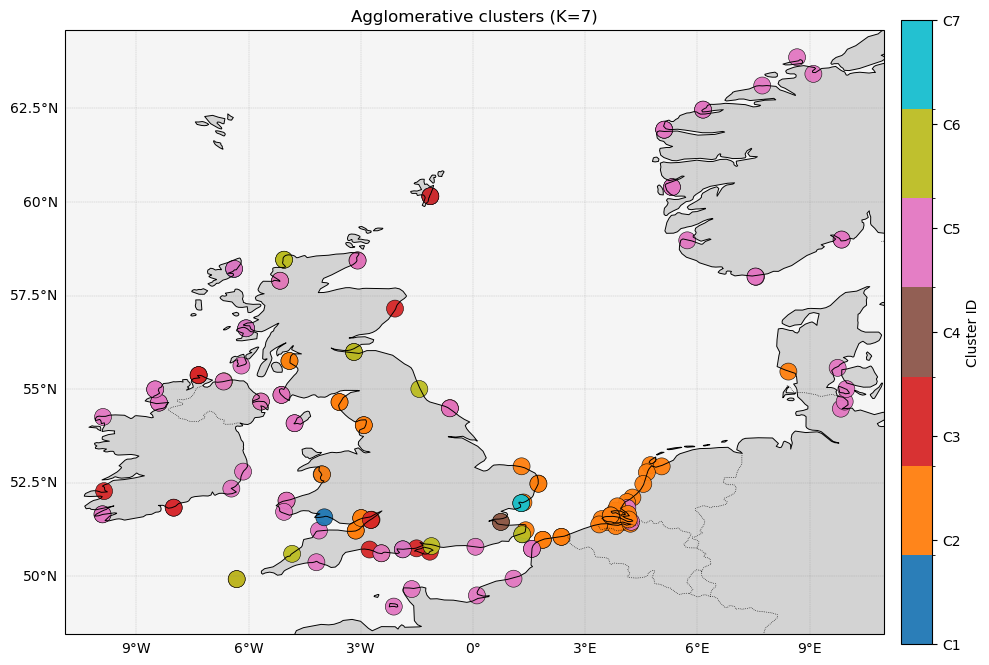

In [59]:
from sklearn.cluster import AgglomerativeClustering

Ks = range(2, 12 + 1)
sil_scores = []
for K in Ks:
    model = AgglomerativeClustering(n_clusters=K, linkage="ward")
    labels_k = model.fit_predict(Xk)
    sil_scores.append(silhouette_score(Xk, labels_k))

best_K = Ks[np.argmax(sil_scores)]
print(f"Best Agglomerative K = {best_K}")

model = AgglomerativeClustering(n_clusters=best_K, linkage="ward")
labels_aggl = model.fit_predict(Xk)
labels_aggl_full = np.full(ds.sizes["station"], np.nan)
labels_aggl_full[mask] = labels_aggl

quick_map(labels_aggl_full, f"Agglomerative clusters (K={best_K})", "Cluster ID",
          cmap="tab10", n_clusters=best_K, vmin=-0.5, vmax=best_K - 0.5)


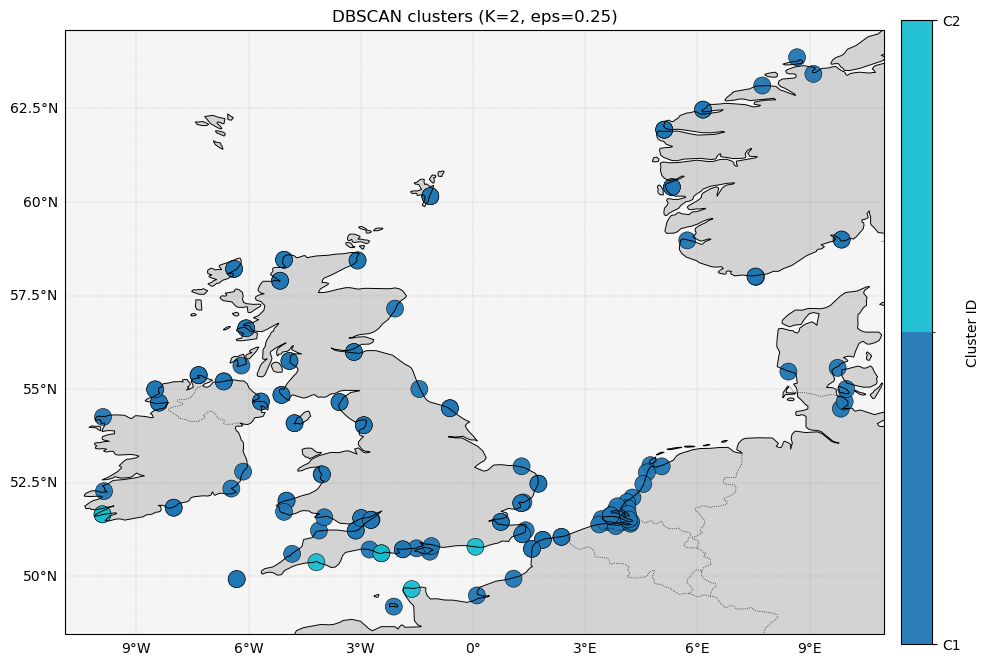

In [61]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

def choose_dbscan_eps(X, eps_grid=None, min_samples=5, metric="euclidean", verbose=True):
    """
    Grid-search eps for DBSCAN using silhouette on non-noise points.
    Returns best_eps and a dict summary for all tried eps.

    Ranking: highest silhouette -> most clustered points -> fewer clusters.
    """
    if eps_grid is None:
        # sensible default sweep (adjust to your scale)
        eps_grid = np.unique(np.round(np.r_[np.linspace(0.05, 2.0, 30),  # fine low range
                                           np.linspace(2.0, 5.0, 10)], 3))

    results = []
    for eps in eps_grid:
        labels = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit_predict(X)
        # Exclude noise for scoring
        mask = labels != -1
        n_clusters = len(set(labels[mask]))
        n_clustered = int(mask.sum())
        frac_clustered = n_clustered / len(labels)

        # Valid silhouette requires at least 2 clusters and >=2 samples
        if n_clusters >= 2 and n_clustered >= 2:
            sil = silhouette_score(X[mask], labels[mask], metric=metric)
        else:
            sil = np.nan

        results.append({
            "eps": float(eps),
            "silhouette": sil,
            "n_clusters": int(n_clusters),
            "n_clustered": n_clustered,
            "frac_clustered": frac_clustered,
            "n_noise": int((~mask).sum()),
        })


    # Rank candidates: max silhouette -> max clustered -> min clusters
    def rank_key(r):
        sil = r["silhouette"]
        return (
            -np.inf if not np.isfinite(sil) else -sil,  # negative for ascending sort
            -r["n_clustered"],
            r["n_clusters"],
        )

    ranked = sorted(results, key=rank_key)
    best = next((r for r in ranked if np.isfinite(r["silhouette"])), None)

    best_eps = best["eps"] if best is not None else None
    return best_eps, results

# 1) Find best eps
best_eps, eps_results = choose_dbscan_eps(Xk, eps_grid=[0.1, 0.2, 0.25, 0.3, 0.5, 0.7, 1.0, 1.5, 3.0],
                                          min_samples=5, metric="euclidean", verbose=True)

# 2) Fit DBSCAN with the chosen eps
model = DBSCAN(eps=best_eps, min_samples=5)
labels_db = model.fit_predict(Xk)

# 3) Map labels back to stations
labels_db_full = np.full(ds.sizes["station"], np.nan)
labels_db_full[mask] = labels_db

# 4) Compute number of *actual* clusters (exclude noise=-1)
unique_labels = set(labels_db) - {-1}
best_K = len(unique_labels)

# 5) Plot (discrete colors = number of clusters)
quick_map(labels_db_full, f"DBSCAN clusters (K={best_K}, eps={best_eps})", "Cluster ID",
          cmap="tab10", n_clusters=best_K, vmin=-0.5, vmax=best_K - 0.5)


In [23]:
from sklearn.cluster import DBSCAN

# try a few epsilons to find stable structure
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 0.2, 0.1, 0.25, 3]
for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels_db = model.fit_predict(Xk)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    if n_clusters > 1:
        sil = silhouette_score(Xk, labels_db)
        print(f"eps={eps:.2f}, clusters={n_clusters}, silhouette={sil:.3f}")

# pick best visually or based on silhouette
best_eps = 0.3  # e.g. from above output
model = DBSCAN(eps=best_eps, min_samples=5)
labels_db = model.fit_predict(Xk)

labels_db_full = np.full(ds.sizes["station"], np.nan)
labels_db_full[mask] = labels_db
best_K = len(np.unique(labels_db))

quick_map(labels_db_full, f"Agglomerative clusters (K={best_K})", "Cluster ID",
          cmap="tab10", n_clusters=best_K, vmin=-0.5, vmax=best_K - 0.5)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 157 but corresponding boolean dimension is 750192

# analysis on the GMM

Best GMM K = 4


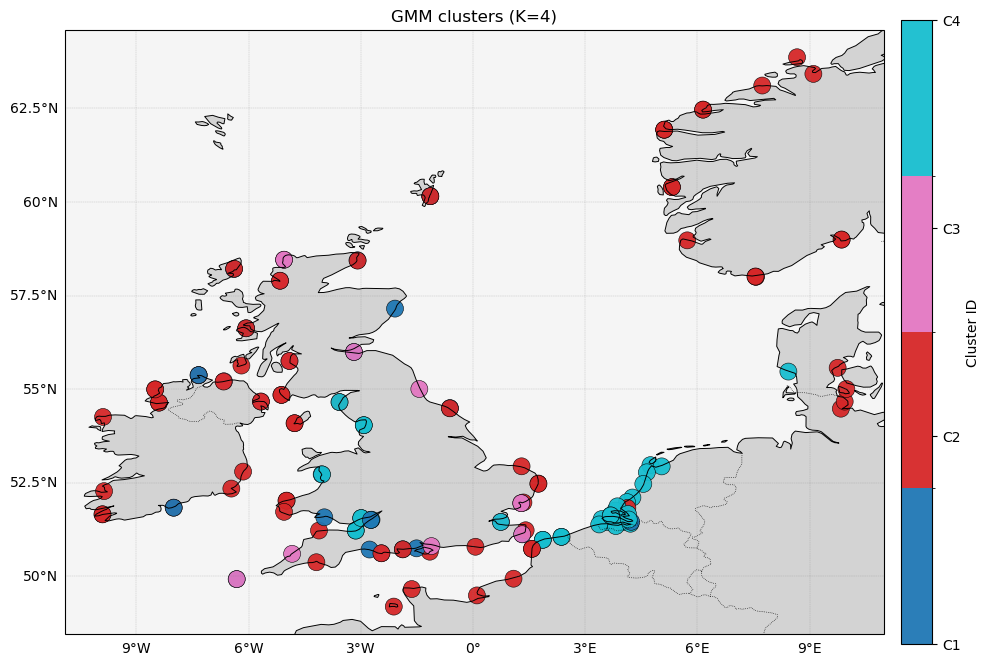

In [66]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

scores = []
Ks = range(2, 12 + 1)
for K in Ks:
    gmm = GaussianMixture(n_components=K, covariance_type="full", random_state=0)
    labels_k = gmm.fit_predict(Xk)
    sil = silhouette_score(Xk, labels_k)
    cal = calinski_harabasz_score(Xk, labels_k)
    dav = davies_bouldin_score(Xk, labels_k)
    scores.append((K, sil, cal, dav))

# pick best K (highest silhouette)
best_K, *_ = max(scores, key=lambda t: t[1])
print(f"Best GMM K = {best_K}")

# final clustering
best_gmm = GaussianMixture(n_components=best_K, covariance_type="full", random_state=0)
labels_gmm = best_gmm.fit_predict(Xk)

labels_gmm_full = np.full(ds.sizes["station"], np.nan)
labels_gmm_full[mask] = labels_gmm

quick_map(labels_gmm_full, f"GMM clusters (K={best_K})", "Cluster ID",
          cmap="tab10",  n_clusters=best_K, vmin=-0.5, vmax=best_K - 0.5)


In [67]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.spatial.distance import cdist

# ---- 0) Helpers --------------------------------------------------------------

def _to_values(x):
    """Safely convert xarray DataArray or numpy-like to np.ndarray."""
    if x is None:
        return None
    try:
        return np.asarray(x.values if hasattr(x, "values") else x)
    except Exception:
        return None

def _maybe_feature(name, label=None):
    """Fetch variable from globals() if present; return (label, array) or None."""
    obj = globals().get(name, None)
    arr = _to_values(obj)
    if arr is None:
        return None
    return (label or name, arr)

def _iqr(a):
    q75 = np.nanpercentile(a, 75)
    q25 = np.nanpercentile(a, 25)
    return q75 - q25

# ---- 1) Collect available per-station features -------------------------------
# Add any other arrays you’ve computed; this list auto-skips missing ones.
candidates = [
    _maybe_feature("mean_res",  "mean"),
    _maybe_feature("std_res",   "std"),
    _maybe_feature("skew_res",  "skew"),
    _maybe_feature("kurt_res",  "kurtosis"),
    _maybe_feature("tenyr_rl",  "tenyr_rl"),
    _maybe_feature("p95_res",   "p95"),
    _maybe_feature("p99_res",   "p99"),
]

feat_dict = {lab: arr for item in candidates if item is not None for lab, arr in [item]}

n_stations = int(ds.sizes["station"])

# Ensure shapes align and drop features with wrong length
feat_dict = {k: v for k, v in feat_dict.items() if np.asarray(v).shape[0] == n_stations}

if not feat_dict:
    raise RuntimeError("No per-station features found. Compute features first (e.g., mean_res, std_res, ...).")

# ---- 2) Build per-station DataFrame ------------------------------------------
# Station identifiers if available
station_ids = None
for key in ["station", "station_name", "name"]:
    if key in ds:
        station_ids = _to_values(ds[key])
        break
if station_ids is None:
    station_ids = np.arange(n_stations)

df = pd.DataFrame(feat_dict)
df.insert(0, "station", station_ids)

# Add GMM cluster labels (full-length, with NaNs for excluded stations)
df["cluster"] = labels_gmm_full

# A mask of stations that participated in clustering (same mask you used for Xk)
# (Assuming 'mask' exists and is boolean for length n_stations)
df["used_in_clustering"] = _to_values(globals().get("mask", np.isfinite(labels_gmm_full)))

# Keep only stations with a valid cluster label for summaries
dfc = df[df["used_in_clustering"] & np.isfinite(df["cluster"])].copy()
dfc["cluster"] = dfc["cluster"].astype(int)

# ---- 3) Silhouette metrics ---------------------------------------------------
# Silhouette requires the scaled matrix Xk and labels for *used* rows.
# Compute per-sample silhouette and aggregate by cluster.
sil_all = silhouette_samples(Xk, labels_gmm, metric="euclidean")
sil_overall = silhouette_score(Xk, labels_gmm, metric="euclidean")
dfc["silhouette"] = sil_all

sil_by_cluster = dfc.groupby("cluster")["silhouette"].agg(["mean", "median", "min", "max"]).rename(
    columns={"mean": "sil_mean", "median": "sil_median", "min": "sil_min", "max": "sil_max"}
)

# ---- 4) Cluster descriptive stats -------------------------------------------
# For numeric features, compute count/mean/median/std/IQR per cluster.
num_cols = [c for c in dfc.columns if c not in ["station", "cluster", "used_in_clustering", "silhouette"]
            and np.issubdtype(np.asarray(dfc[c]).dtype, np.number)]

def agg_iqr(x): return pd.Series({"iqr": _iqr(x.values)})
agg_basic = dfc.groupby("cluster")[num_cols].agg(["count", "mean", "median", "std", "min", "max"])
# Tidy column order
agg_basic = agg_basic.sort_index(axis=1, level=0)

# ---- 5) Distinguishing features per cluster (z-score of cluster mean vs global) ----
global_mean = dfc[num_cols].mean(axis=0)
global_std  = dfc[num_cols].std(axis=0).replace(0, np.nan)

cluster_means = dfc.groupby("cluster")[num_cols].mean()
z_scores = (cluster_means - global_mean) / global_std  # how many global stds away

# For each cluster, list top features by |z| (most over/under-expressed)
topk = 5
top_features_by_cluster = {}
for c in z_scores.index:
    z = z_scores.loc[c].copy()
    z_abs = z.abs().sort_values(ascending=False)
    top = pd.DataFrame({"z": z.loc[z_abs.index], "z_abs": z_abs.values})
    top_features_by_cluster[c] = top.head(topk)

# ---- 6) Cluster medoids (representative stations in scaled space) -----------
# Compute centroids in *scaled* feature space (Xk) and nearest actual points as medoids.
centroids = []
medoids = []   # (cluster, station_id, distance)
start_idx = 0
# Build an index map from used rows to station rows
used_idx = np.where(df["used_in_clustering"].values)[0]

for c in np.unique(labels_gmm):
    idx = np.where(labels_gmm == c)[0]         # indices within Xk / used rows
    Xc = Xk[idx]
    centroid = Xc.mean(axis=0, keepdims=True)
    d = cdist(Xc, centroid).ravel()
    j = idx[np.argmin(d)]                      # index within used rows
    station_row = used_idx[j]                  # original station index
    centroids.append(centroid.ravel())
    medoids.append({"cluster": int(c),
                    "station_index": int(station_row),
                    "station": df.loc[station_row, "station"],
                    "distance": float(d.min())})

medoids_df = pd.DataFrame(medoids).sort_values(["cluster", "distance"])

# ---- 7) Friendly summaries to read ------------------------------------------
print("\n=== Overall silhouette (on used points) ===")
print(f"{sil_overall:.3f}")

print("\n=== Per-cluster silhouette summary ===")
print(sil_by_cluster.round(3))

print("\n=== Cluster sizes ===")
print(dfc.groupby("cluster").size().rename("n_points"))

print("\n=== Per-cluster numeric feature summary (count/mean/median/std/min/max/iqr) ===")
# MultiIndex columns; display a subset or all:
with pd.option_context("display.max_rows", 200, "display.max_columns", 200):
    print(agg_basic.round(3))

print("\n=== Top distinguishing features per cluster (by |z| vs global mean) ===")
for c, top in top_features_by_cluster.items():
    print(f"\nCluster {c}:")
    print(top.round(3))

print("\n=== Cluster medoids (representative stations) ===")
print(medoids_df)

# ---- 8) OPTIONAL: export to CSV for inspection -------------------------------
# dfc.to_csv("stations_with_clusters.csv", index=False)
# agg_basic.to_csv("cluster_feature_summary.csv")
# z_scores.to_csv("cluster_feature_zscores_vs_global.csv")
# medoids_df.to_csv("cluster_medoids.csv", index=False)



=== Overall silhouette (on used points) ===
0.396

=== Per-cluster silhouette summary ===
         sil_mean  sil_median  sil_min  sil_max
cluster                                        
0           0.006       0.040   -0.459    0.240
1           0.497       0.611   -0.302    0.695
2           0.150       0.164   -0.183    0.388
3           0.511       0.568    0.065    0.651

=== Cluster sizes ===
cluster
0    18
1    69
2    16
3    35
Name: n_points, dtype: int64

=== Per-cluster numeric feature summary (count/mean/median/std/min/max/iqr) ===
        kurtosis                                        mean                \
           count     max    mean  median    min    std count    max   mean   
cluster                                                                      
0             18  28.419  13.786  12.992 -1.403  6.704    18  0.229  0.030   
1             69   9.397   2.362   1.662 -0.014  2.127    69  0.015  0.002   
2             16  15.211  10.857  10.622  6.237  2.796    

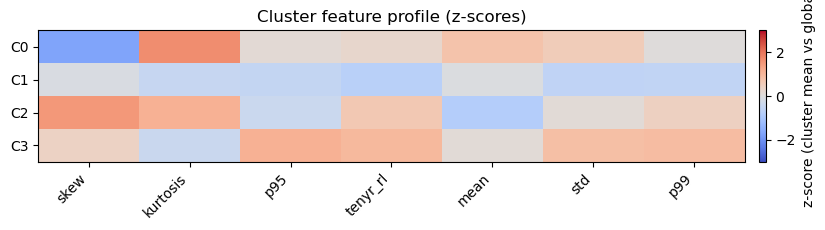

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Sort features by overall variance in z to emphasize most discriminative
zs = z_scores.copy()
feat_order = zs.var(axis=0).sort_values(ascending=False).index
zs = zs[feat_order]

plt.figure(figsize=(1.2*len(feat_order), 0.6*len(zs)))
im = plt.imshow(zs.values, aspect='auto', interpolation='nearest', cmap='coolwarm', vmin=-3, vmax=3)
plt.colorbar(im, fraction=0.02, pad=0.02, label='z-score (cluster mean vs global)')
plt.yticks(ticks=np.arange(len(zs.index)), labels=[f"C{c}" for c in zs.index])
plt.xticks(ticks=np.arange(len(feat_order)), labels=feat_order, rotation=45, ha='right')
plt.title("Cluster feature profile (z-scores)")
plt.tight_layout()
plt.show()


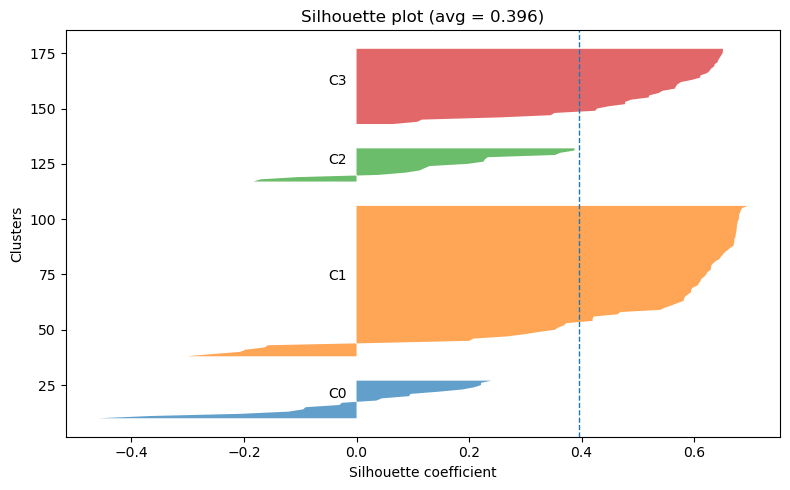

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score

silhouette_vals = silhouette_samples(Xk, labels_gmm, metric='euclidean')
silhouette_avg  = silhouette_score(Xk, labels_gmm, metric='euclidean')
clusters = np.unique(labels_gmm)

y_lower = 10
plt.figure(figsize=(8, 5))
for c in clusters:
    c_sil = np.sort(silhouette_vals[labels_gmm == c])
    c_size = len(c_sil)
    y_upper = y_lower + c_size
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * c_size, f"C{c}")
    y_lower = y_upper + 10

plt.axvline(silhouette_avg, linestyle='--', linewidth=1)
plt.xlabel("Silhouette coefficient")
plt.ylabel("Clusters")
plt.title(f"Silhouette plot (avg = {silhouette_avg:.3f})")
plt.tight_layout()
plt.show()


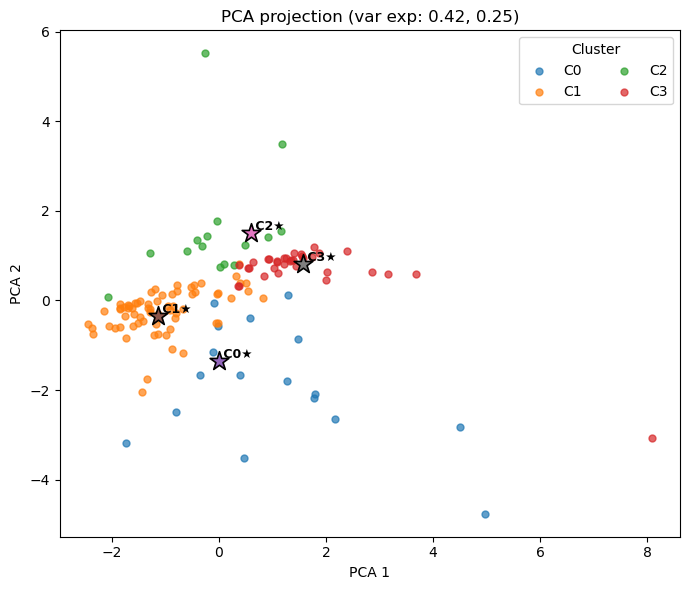

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(Xk)

plt.figure(figsize=(7,6))
for c in np.unique(labels_gmm):
    pts = X2[labels_gmm == c]
    plt.scatter(pts[:,0], pts[:,1], s=25, alpha=0.7, label=f"C{c}")

# Highlight medoids if available (computed in earlier block)
if 'medoids_df' in globals():
    # map used rows (Xk order) back to station indices
    used_idx = np.where(dfc.index.isin(dfc.index))[0]  # dfc is already filtered; Xk rows line up with dfc rows
    # safer: rebuild mapping explicitly
    # Build mapping from cluster -> nearest representative in X2 using same logic as before
    for _, row in medoids_df.iterrows():
        c = int(row['cluster'])
        # station index in original df
        st_idx = int(row['station_index'])
        # find this station's row in dfc (index alignment)
        i = dfc.index.get_loc(st_idx) if st_idx in dfc.index else None
        if i is not None:
            x, y = X2[i, 0], X2[i, 1]
            plt.scatter([x], [y], s=200, marker='*', edgecolor='k', linewidth=1.2)
            plt.text(x, y, f" C{c}★", fontsize=9, weight='bold', va='bottom', ha='left')

plt.legend(title="Cluster", ncol=2)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
ev = pca.explained_variance_ratio_
plt.title(f"PCA projection (var exp: {ev[0]:.2f}, {ev[1]:.2f})")
plt.tight_layout()
plt.show()


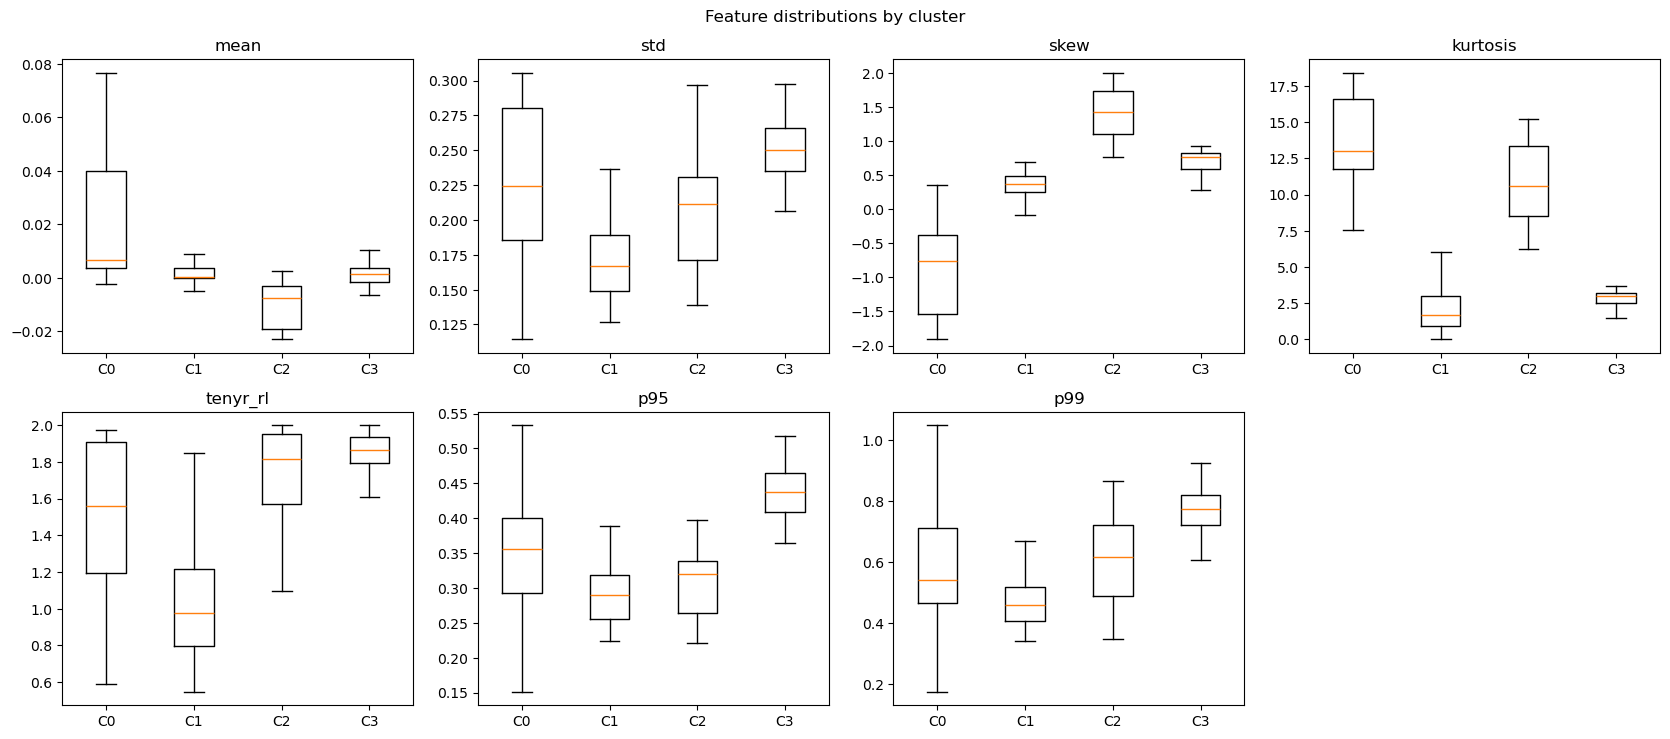

In [71]:
import numpy as np
import matplotlib.pyplot as plt

clusters = sorted(dfc['cluster'].unique().tolist())
sel_feats = num_cols  # or pick a subset, e.g.: ['std','skew','kurtosis','tenyr_rl','p95']

n = len(sel_feats)
cols = min(4, n)
rows = int(np.ceil(n / cols))

plt.figure(figsize=(4.2*cols, 3.6*rows))
for i, feat in enumerate(sel_feats, 1):
    plt.subplot(rows, cols, i)
    data = [dfc.loc[dfc['cluster']==c, feat].dropna().values for c in clusters]
    plt.boxplot(data, showfliers=False)
    plt.xticks(ticks=np.arange(1, len(clusters)+1), labels=[f"C{c}" for c in clusters], rotation=0)
    plt.title(feat)
    plt.tight_layout()
plt.suptitle("Feature distributions by cluster", y=1.02, fontsize=12)
plt.show()
